In [47]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [48]:
WORKLOADS = ["faiss_10M", "lulesh2.0_s400", "DuckDB-TPCH-sf100", "DuckDB-TPCDS-sf100", "mg.D.x", "XSBench", "pr-kron.sg", "pr-twitter.sg", "bc-kron.sg", "bc-twitter.sg"]

In [49]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""

    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return (int(match.group(1)) // 100) * 100 if match else None


def extract_run(path: Path) -> int | None:
    match = re.search(r"run(\d+)", path.name)
    return int(match.group(1)) if match else None

def parse_l2_value(raw: str) -> bool | int | float | str:
    if raw == "true":
        return True
    if raw == "false":
        return False
    if re.fullmatch(r"\d+", raw):
        return int(raw)
    if re.fullmatch(r"\d+\.\d+", raw):
        return float(raw)
    return raw

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [50]:
def generate_df(roots_gen: callable) -> pd.DataFrame:
    dfs = []

    for workload in WORKLOADS:
        records: list[dict] = []
        for label, (kernel, root) in roots_gen(workload).items():
            for path in sorted(root.glob("*.time")):
                if "train" in path.name:
                    continue
                metrics = parse_time_file(path)
                try:
                    log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
                except FileNotFoundError:
                    log_metrics = {}

                m = re.search(
                    r"^(?P<mib>\d+)MiB_run(?P<run>\d+)_(?P<model>[^_]+)_discounted_reward_(?P<discounted_reward>\d+)_(?P<workload>.+)_l2-(?P<l2>[^_]+)_(?P<hist_length>\d+)_(?P<penalty>[0-9]+(?:\.[0-9]+)?)(?:\.time)?$",
                    path.name,
                )
                parsed = {}
                if m:
                    l2_value = parse_l2_value(m.group("l2"))
                    parsed = {
                        "MiB": int(m.group("mib")) // 100 * 100,
                        "run": int(m.group("run")),
                        "model": m.group("model"),
                        "filename_workload": m.group("workload"),
                        "discounted_reward": int(m.group("discounted_reward")),
                        "l2": l2_value,
                        "minmax": l2_value if isinstance(l2_value, bool) else None,
                        "hist_length": int(m.group("hist_length")),
                        "penalty": float(m.group("penalty")),
                    }

                records.append({
                    "policy": label,
                    "kernel": kernel,
                    "file": path.name,
                    "MiB": extract_mib(path),
                    "run": extract_run(path),
                    **metrics,
                    **log_metrics,
                    **parsed,
                })

        df = pd.DataFrame(records)
        df["workload"] = workload

        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    return df

In [51]:
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
import matplotlib.pyplot as plt

FIXED_POLICY_COLORS = {
    "manta": "#377eb8",
    "arms": "#ff7f00",
    "tpp": "#984ea3",
    "nomad": "#e41a1c",
    "hybridtier": "#4daf4a",
}

FALLBACK_POLICY_COLORS = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#2ec3da",
    "#a6761d",
    "#f781bf",
]

PENALTY_GRADIENT_BASE = "#e7298a"
PENALTY_BASELINE_GAP_FACTOR = 0.45

def normalize_policy_name(name: object) -> str:
    return str(name).strip().lower()

def build_penalty_gradient_palette(
    plot_data: pd.DataFrame,
    hue_col: str,
    policy_order: list[str],
) -> dict[str, str | tuple[float, float, float]]:
    palette: dict[str, str | tuple[float, float, float]] = {}
    label_details = (
        plot_data[[hue_col, "policy", "penalty"]]
        .drop_duplicates(subset=[hue_col])
        .set_index(hue_col)
    )

    gradient_labels = []
    for label in policy_order:
        if label in label_details.index:
            base_policy = normalize_policy_name(label_details.at[label, "policy"])
        else:
            base_policy = normalize_policy_name(label)

        if base_policy in FIXED_POLICY_COLORS:
            palette[label] = FIXED_POLICY_COLORS[base_policy]
        else:
            gradient_labels.append(label)

    if gradient_labels:
        gradient_frame = (
            label_details.loc[gradient_labels].reset_index()
            .sort_values("penalty", na_position="last")
        )
        ordered_gradient_labels = gradient_frame[hue_col].tolist()
        gradient_colors = sns.light_palette(
            PENALTY_GRADIENT_BASE,
            n_colors=len(ordered_gradient_labels) + 2,
        )[1:-1]
        for label, color in zip(ordered_gradient_labels, gradient_colors):
            palette[label] = color

    return {label: palette[label] for label in policy_order}

def build_policy_palette(policy_order: list[str]) -> dict[str, str | tuple[float, float, float]]:
    palette: dict[str, str | tuple[float, float, float]] = {}
    remaining_colors = [
        color for color in FALLBACK_POLICY_COLORS if color not in FIXED_POLICY_COLORS.values()
    ]
    remaining_index = 0

    for label in policy_order:
        normalized = normalize_policy_name(label)
        if normalized in FIXED_POLICY_COLORS:
            palette[label] = FIXED_POLICY_COLORS[normalized]
        else:
            palette[label] = remaining_colors[remaining_index % len(remaining_colors)]
            remaining_index += 1

    return palette

def apply_penalty_baseline_gap(
    ax,
    bar_containers,
    workload_df: pd.DataFrame,
    hue_col: str,
    local_hue_order: list[str],
    model_policy_key: str,
):
    if hue_col != "policy_penalty" or len(local_hue_order) < 2 or not bar_containers:
        return

    baseline_count = 0
    for label in local_hue_order:
        matching_rows = workload_df.loc[workload_df[hue_col] == label, "policy"]
        if matching_rows.empty:
            break
        if normalize_policy_name(matching_rows.iloc[0]) != model_policy_key:
            break
        baseline_count += 1

    if baseline_count == 0 or baseline_count >= len(bar_containers):
        return

    first_patch = next((patch for patch in bar_containers[0].patches if patch.get_width() > 0), None)
    if first_patch is None:
        return

    gap = first_patch.get_width() * PENALTY_BASELINE_GAP_FACTOR
    line_index = 0
    for container_index, container in enumerate(bar_containers):
        shift = gap if container_index >= baseline_count else 0.0
        for patch in container.patches:
            if shift:
                patch.set_x(patch.get_x() + shift)
            if line_index < len(ax.lines) and shift:
                line = ax.lines[line_index]
                line.set_xdata([x + shift for x in line.get_xdata()])
            line_index += 1

def add_memory_partition_lines(ax, bar_containers):
    if not bar_containers:
        return

    group_spans = []
    group_count = max((len(container.patches) for container in bar_containers), default=0)
    for patch_index in range(group_count):
        group_patches = []
        for container in bar_containers:
            if patch_index >= len(container.patches):
                continue
            patch = container.patches[patch_index]
            if patch.get_width() <= 0 or pd.isna(patch.get_height()):
                continue
            group_patches.append(patch)

        if not group_patches:
            continue

        group_left = min(patch.get_x() for patch in group_patches)
        group_right = max(patch.get_x() + patch.get_width() for patch in group_patches)
        group_spans.append((group_left, group_right))

    for (_, left_group_right), (right_group_left, _) in zip(group_spans, group_spans[1:]):
        ax.axvline(
            (left_group_right + right_group_left) / 2,
            color="#9a9a9a",
            linewidth=0.95,
            alpha=0.75,
            zorder=0,
        )

def plot_df(
    df: pd.DataFrame,
    system_name: str,
    show_penalty_scaler: bool = False,
    model_policy: str = "MANTA",
):
    plot_data = df.copy()
    hue_col = "policy_penalty" if show_penalty_scaler else "policy"
    bar_saturation = 0.65
    model_policy_key = normalize_policy_name(model_policy)

    if hue_col == "policy_penalty" and "policy_penalty" not in plot_data.columns:
        plot_data["policy_penalty"] = plot_data.apply(
            lambda row: f"{row['policy']} {row['penalty']}" if pd.notna(row.get("penalty")) else row["policy"],
            axis=1,
        )

    if show_penalty_scaler and "penalty" in plot_data.columns and plot_data["penalty"].notna().any():
        policy_order = (
            plot_data[[hue_col, "penalty"]]
            .drop_duplicates(subset=[hue_col])
            .sort_values("penalty", na_position="last")
            [hue_col]
            .tolist()
        )
    else:
        policy_order = list(dict.fromkeys(plot_data[hue_col]))

    if show_penalty_scaler:
        policy_palette = build_penalty_gradient_palette(plot_data, hue_col, policy_order)
    else:
        policy_palette = build_policy_palette(policy_order)

    legend_facecolors = {
        name: sns.desaturate(policy_palette[name], bar_saturation)
        for name in policy_order
    }

    def minmax_interval(values):
        s = pd.Series(values).dropna()
        if s.empty:
            return (0.0, 0.0)
        return (float(s.min()), float(s.max()))

    def darken_color(color, factor=0.3):
        r, g, b, a = to_rgba(color)
        return (r * factor, g * factor, b * factor, a)

    for workload, workload_df in plot_data.groupby("workload", observed=True):
        
        plt.figure(figsize=(4, 2.75))

        # Use only policies present in this workload to avoid "missing" bars
        local_hue_order = [p for p in policy_order if p in set(workload_df[hue_col])]
        x_order = sorted(workload_df["MiB"].dropna().unique())

        ax = sns.barplot(
            data=workload_df,
            x="MiB",
            y="real",
            hue=hue_col,
            order=x_order,
            hue_order=local_hue_order,
            palette=policy_palette,
            saturation=bar_saturation,
            estimator="mean",
            errorbar=minmax_interval,
        )
        fig = ax.figure
        ax.set(xlabel="Memory Footprint (MiB)", ylabel="Execution Time (s)")

        bar_containers = [container for container in ax.containers if hasattr(container, "datavalues")]
        apply_penalty_baseline_gap(
            ax,
            bar_containers,
            workload_df,
            hue_col,
            local_hue_order,
            model_policy_key,
        )
        add_memory_partition_lines(ax, bar_containers)
        for container in bar_containers:
            for patch in container.patches:
                patch.set_edgecolor(darken_color(patch.get_facecolor()))
                patch.set_linewidth(1.2)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax + 0.10 * (ymax - ymin))

        group_cols = ["MiB", "policy"] if hue_col == "policy" else ["MiB", "policy", hue_col]
        bar_stats = (
            workload_df.groupby(group_cols, observed=True)
            .agg(
                bar_value=("real", "mean"),
                err_top=("real", lambda s: minmax_interval(s)[1]),
            )
            .reset_index()
        )

        label_lookup = {
            (row[hue_col], row["MiB"]): (row["bar_value"], row["err_top"])
            for _, row in bar_stats.iterrows()
        }

        model_lookup = (
            bar_stats[bar_stats["policy"].astype(str).str.lower() == model_policy_key]
            .groupby("MiB", observed=True)["bar_value"]
            .mean()
            .to_dict()
        )

        comparison_rows = []
        for _, row in bar_stats.iterrows():
            mib = row["MiB"]
            label_name = row[hue_col]
            bar_value = float(row["bar_value"])
            model_value = model_lookup.get(mib)

            if model_value is None or pd.isna(model_value):
                model_value_out = float("nan")
                delta = float("nan")
                pct = float("nan")
                ratio = float("nan")
            else:
                model_value_out = float(model_value)
                delta = bar_value - model_value_out

                if model_value_out == 0:
                    pct = float("nan")
                    ratio = float("nan")
                else:
                    pct = 100.0 * delta / model_value_out
                    ratio = bar_value / model_value_out

            comparison_rows.append(
                {
                    "MiB": mib,
                    hue_col: label_name,
                    "real_mean_s": bar_value,
                    "model_mean_s": model_value_out,
                    "delta_s": delta,
                    "pct_vs_model": pct,
                    "ratio_vs_model": ratio,
                }
            )

        annotations = []
        for hue_name, container in zip(local_hue_order, bar_containers):
            for mib, patch in zip(x_order, container.patches):
                stats = label_lookup.get((hue_name, mib))
                if stats is None:
                    continue

                bar_value, err_top = stats
                if pd.isna(bar_value) or pd.isna(err_top):
                    continue

                text = f"{bar_value:.2f}"

                ann = ax.annotate(
                    text,
                    xy=(patch.get_x() + patch.get_width() / 2, err_top),
                    xytext=(0.65, 3),
                    textcoords="offset points",
                    ha="left",
                    va="center",
                    rotation=90,
                    rotation_mode="anchor",
                    fontsize=8,
                )

                annotations.append(ann)

        if ax.legend_ is not None:
            ax.legend_.remove()

        fig.tight_layout()

        if annotations:
            for _ in range(10):
                fig.canvas.draw()
                renderer = fig.canvas.get_renderer()
                ymin, ymax = ax.get_ylim()
                max_text_y = ymax

                for ann in annotations:
                    bbox = ann.get_window_extent(renderer=renderer)
                    bbox_data = bbox.transformed(ax.transData.inverted())
                    max_text_y = max(max_text_y, bbox_data.ymax)

                if max_text_y <= ymax:
                    break

                pad = 0.02 * max(ymax - ymin, 1.0)
                ax.set_ylim(ymin, max_text_y + pad)
                fig.tight_layout()

        plt.savefig(f"plot_{system_name}_{workload}.pdf")
        plt.show()

        comparison_df = pd.DataFrame(comparison_rows)
        if comparison_df["model_mean_s"].notna().any():
            comparison_df[hue_col] = pd.Categorical(
                comparison_df[hue_col],
                categories=local_hue_order,
                ordered=True,
            )
            comparison_df = comparison_df.sort_values(["MiB", hue_col])

            print(f"Comparison to '{model_policy}' at same MiB")
            columns_to_print = [
                "MiB",
                hue_col,
                "real_mean_s",
                "model_mean_s",
                "delta_s",
                "pct_vs_model",
                "ratio_vs_model",
            ]
            print(workload)
            print(
                comparison_df[comparison_df[hue_col] != model_policy][columns_to_print].to_string(
                    index=False,
                    float_format=lambda x: f"{x:.2f}",
                )
            )
        else:
            print(f"No '{model_policy}' rows found for workload '{workload}'.")

        print()

    # Combined legend with visible box
    legend_handles = [
        Patch(
            facecolor=legend_facecolors[name],
            edgecolor=darken_color(legend_facecolors[name]),
            linewidth=1,
            label=name,
        )
        for name in policy_order
    ]
    plt.figure(figsize=(16, 1.3))
    plt.legend(
        handles=legend_handles,
        loc="center",
        ncol=len(legend_handles),
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        edgecolor="black",
    )
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"legend_{system_name}_legend.pdf")
    plt.show()

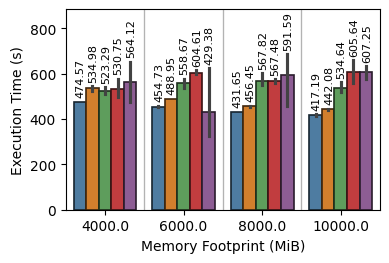

Comparison to 'MANTA' at same MiB
DuckDB-TPCH-sf100
     MiB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00       ARMS       534.98        474.57    60.41         12.73            1.13
 4000.00 HybridTier       523.29        474.57    48.72         10.27            1.10
 4000.00      Nomad       530.75        474.57    56.18         11.84            1.12
 4000.00        TPP       564.12        474.57    89.55         18.87            1.19
 6000.00       ARMS       488.95        454.73    34.22          7.52            1.08
 6000.00 HybridTier       558.67        454.73   103.94         22.86            1.23
 6000.00      Nomad       604.61        454.73   149.87         32.96            1.33
 6000.00        TPP       429.38        454.73   -25.36         -5.58            0.94
 8000.00       ARMS       456.45        431.65    24.80          5.75            1.06
 8000.00 HybridTier       567.82        431.65   136.18         31.55            1.32
 8

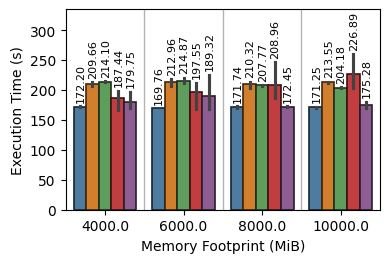

Comparison to 'MANTA' at same MiB
XSBench
     MiB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00       ARMS       209.66        172.20    37.46         21.76            1.22
 4000.00 HybridTier       214.10        172.20    41.91         24.34            1.24
 4000.00      Nomad       187.44        172.20    15.24          8.85            1.09
 4000.00        TPP       179.75        172.20     7.56          4.39            1.04
 6000.00       ARMS       212.96        169.76    43.20         25.45            1.25
 6000.00 HybridTier       214.87        169.76    45.11         26.57            1.27
 6000.00      Nomad       197.55        169.76    27.79         16.37            1.16
 6000.00        TPP       189.32        169.76    19.56         11.52            1.12
 8000.00       ARMS       210.32        171.74    38.58         22.47            1.22
 8000.00 HybridTier       207.77        171.74    36.04         20.98            1.21
 8000.00    

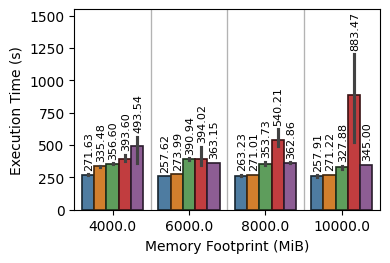

Comparison to 'MANTA' at same MiB
bc-kron.sg
     MiB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00       ARMS       335.48        271.63    63.84         23.50            1.24
 4000.00 HybridTier       356.60        271.63    84.97         31.28            1.31
 4000.00      Nomad       393.60        271.63   121.97         44.90            1.45
 4000.00        TPP       493.54        271.63   221.90         81.69            1.82
 6000.00       ARMS       273.99        257.62    16.36          6.35            1.06
 6000.00 HybridTier       390.94        257.62   133.31         51.75            1.52
 6000.00      Nomad       394.02        257.62   136.40         52.94            1.53
 6000.00        TPP       363.15        257.62   105.52         40.96            1.41
 8000.00       ARMS       271.01        263.23     7.78          2.96            1.03
 8000.00 HybridTier       353.73        263.23    90.50         34.38            1.34
 8000.00 

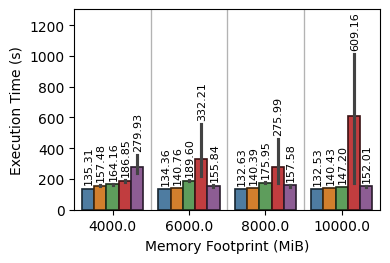

Comparison to 'MANTA' at same MiB
bc-twitter.sg
     MiB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00       ARMS       157.48        135.31    22.17         16.38            1.16
 4000.00 HybridTier       164.16        135.31    28.84         21.32            1.21
 4000.00      Nomad       186.85        135.31    51.54         38.09            1.38
 4000.00        TPP       279.93        135.31   144.62        106.88            2.07
 6000.00       ARMS       140.76        134.36     6.41          4.77            1.05
 6000.00 HybridTier       189.60        134.36    55.24         41.11            1.41
 6000.00      Nomad       332.21        134.36   197.85        147.25            2.47
 6000.00        TPP       155.84        134.36    21.49         15.99            1.16
 8000.00       ARMS       140.39        132.63     7.76          5.85            1.06
 8000.00 HybridTier       175.95        132.63    43.32         32.66            1.33
 8000.

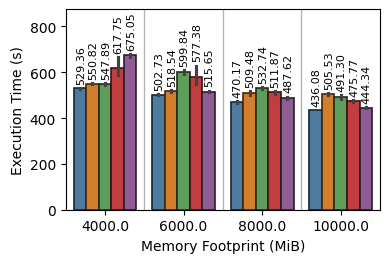

Comparison to 'MANTA' at same MiB
faiss_10M
     MiB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00       ARMS       550.82        529.36    21.46          4.05            1.04
 4000.00 HybridTier       547.89        529.36    18.53          3.50            1.04
 4000.00      Nomad       617.75        529.36    88.40         16.70            1.17
 4000.00        TPP       675.05        529.36   145.70         27.52            1.28
 6000.00       ARMS       518.54        502.73    15.81          3.15            1.03
 6000.00 HybridTier       599.84        502.73    97.11         19.32            1.19
 6000.00      Nomad       577.38        502.73    74.65         14.85            1.15
 6000.00        TPP       515.65        502.73    12.92          2.57            1.03
 8000.00       ARMS       509.48        470.17    39.31          8.36            1.08
 8000.00 HybridTier       532.74        470.17    62.58         13.31            1.13
 8000.00  

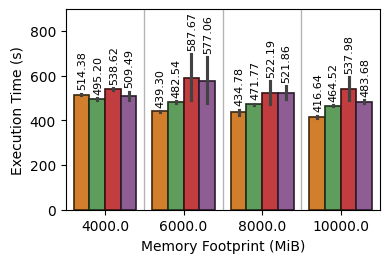

No 'MANTA' rows found for workload 'lulesh2.0_s400'.



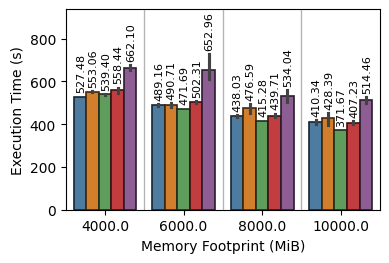

Comparison to 'MANTA' at same MiB
mg.D.x
     MiB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00       ARMS       553.06        527.48    25.58          4.85            1.05
 4000.00 HybridTier       539.40        527.48    11.92          2.26            1.02
 4000.00      Nomad       558.44        527.48    30.96          5.87            1.06
 4000.00        TPP       662.10        527.48   134.62         25.52            1.26
 6000.00       ARMS       490.71        489.16     1.55          0.32            1.00
 6000.00 HybridTier       471.69        489.16   -17.46         -3.57            0.96
 6000.00      Nomad       502.31        489.16    13.15          2.69            1.03
 6000.00        TPP       652.96        489.16   163.80         33.49            1.33
 8000.00       ARMS       476.59        438.03    38.56          8.80            1.09
 8000.00 HybridTier       415.28        438.03   -22.75         -5.19            0.95
 8000.00     

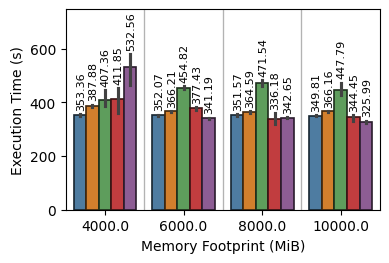

Comparison to 'MANTA' at same MiB
pr-kron.sg
     MiB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00       ARMS       387.88        353.36    34.53          9.77            1.10
 4000.00 HybridTier       407.36        353.36    54.00         15.28            1.15
 4000.00      Nomad       411.85        353.36    58.49         16.55            1.17
 4000.00        TPP       532.56        353.36   179.21         50.72            1.51
 6000.00       ARMS       366.21        352.07    14.14          4.02            1.04
 6000.00 HybridTier       454.82        352.07   102.76         29.19            1.29
 6000.00      Nomad       377.43        352.07    25.36          7.20            1.07
 6000.00        TPP       341.19        352.07   -10.88         -3.09            0.97
 8000.00       ARMS       364.59        351.57    13.02          3.70            1.04
 8000.00 HybridTier       471.54        351.57   119.96         34.12            1.34
 8000.00 

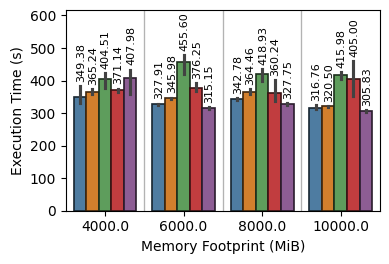

Comparison to 'MANTA' at same MiB
pr-twitter.sg
     MiB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00       ARMS       365.24        349.38    15.87          4.54            1.05
 4000.00 HybridTier       404.51        349.38    55.14         15.78            1.16
 4000.00      Nomad       371.14        349.38    21.76          6.23            1.06
 4000.00        TPP       407.98        349.38    58.61         16.77            1.17
 6000.00       ARMS       345.98        327.91    18.07          5.51            1.06
 6000.00 HybridTier       455.60        327.91   127.69         38.94            1.39
 6000.00      Nomad       376.25        327.91    48.34         14.74            1.15
 6000.00        TPP       315.15        327.91   -12.76         -3.89            0.96
 8000.00       ARMS       364.46        342.78    21.68          6.32            1.06
 8000.00 HybridTier       418.93        342.78    76.15         22.21            1.22
 8000.

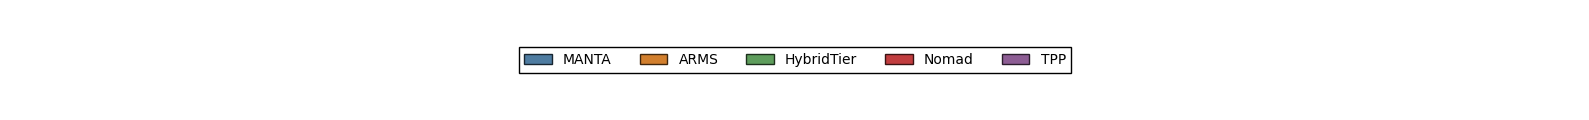

In [52]:
roots_6_2 = lambda workload: {
        "MANTA": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.2/{workload}")),
        "ARMS": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/arms_6.2/{workload}")),
        "HybridTier": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/hybridtier/{workload}")),
        "Nomad": ("5.15-rc6+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/nomad/{workload}")),
        "TPP": ("5.15+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/tpp/{workload}")),
    }

df = generate_df(roots_6_2)
df_plot = df[df["MiB"].isin([4000, 6000, 8000, 10000])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)
plot_df(df_plot, "6_2")

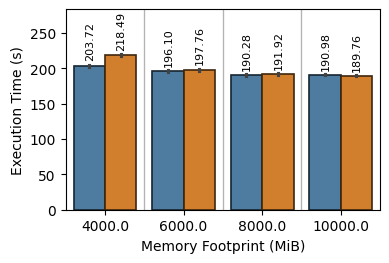

Comparison to 'MANTA' at same MiB
DuckDB-TPCH-sf100
     MiB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00   ARMS       218.49        203.72    14.78          7.25            1.07
 6000.00   ARMS       197.76        196.10     1.66          0.85            1.01
 8000.00   ARMS       191.92        190.28     1.64          0.86            1.01
10000.00   ARMS       189.76        190.98    -1.22         -0.64            0.99



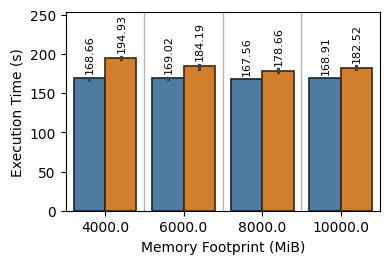

Comparison to 'MANTA' at same MiB
XSBench
     MiB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00   ARMS       194.93        168.66    26.27         15.58            1.16
 6000.00   ARMS       184.19        169.02    15.16          8.97            1.09
 8000.00   ARMS       178.66        167.56    11.10          6.62            1.07
10000.00   ARMS       182.52        168.91    13.61          8.06            1.08



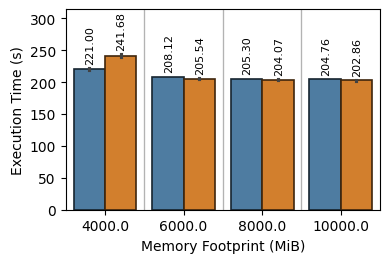

Comparison to 'MANTA' at same MiB
bc-kron.sg
     MiB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00   ARMS       241.68        221.00    20.68          9.36            1.09
 6000.00   ARMS       205.54        208.12    -2.58         -1.24            0.99
 8000.00   ARMS       204.07        205.30    -1.23         -0.60            0.99
10000.00   ARMS       202.86        204.76    -1.90         -0.93            0.99



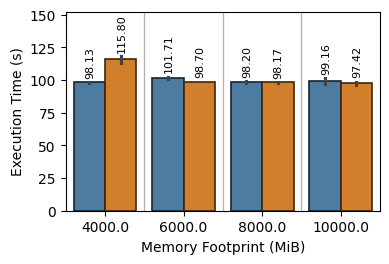

Comparison to 'MANTA' at same MiB
bc-twitter.sg
     MiB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00   ARMS       115.80         98.13    17.68         18.02            1.18
 6000.00   ARMS        98.70        101.71    -3.01         -2.96            0.97
 8000.00   ARMS        98.17         98.20    -0.03         -0.03            1.00
10000.00   ARMS        97.42         99.16    -1.74         -1.75            0.98



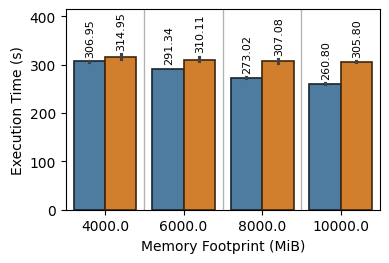

Comparison to 'MANTA' at same MiB
faiss_10M
     MiB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00   ARMS       314.95        306.95     8.00          2.61            1.03
 6000.00   ARMS       310.11        291.34    18.77          6.44            1.06
 8000.00   ARMS       307.08        273.02    34.06         12.48            1.12
10000.00   ARMS       305.80        260.80    45.01         17.26            1.17



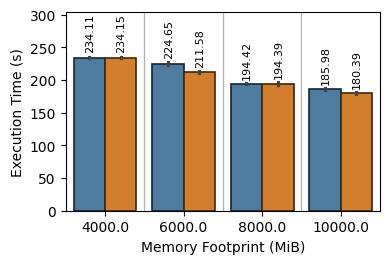

Comparison to 'MANTA' at same MiB
mg.D.x
     MiB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00   ARMS       234.15        234.11     0.03          0.01            1.00
 6000.00   ARMS       211.58        224.65   -13.07         -5.82            0.94
 8000.00   ARMS       194.39        194.42    -0.03         -0.01            1.00
10000.00   ARMS       180.39        185.98    -5.59         -3.00            0.97



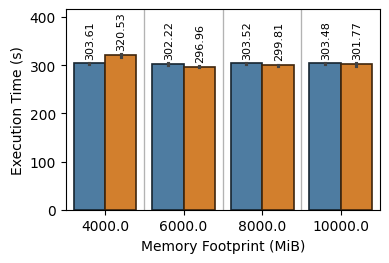

Comparison to 'MANTA' at same MiB
pr-kron.sg
     MiB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00   ARMS       320.53        303.61    16.92          5.57            1.06
 6000.00   ARMS       296.96        302.22    -5.26         -1.74            0.98
 8000.00   ARMS       299.81        303.52    -3.71         -1.22            0.99
10000.00   ARMS       301.77        303.48    -1.72         -0.57            0.99



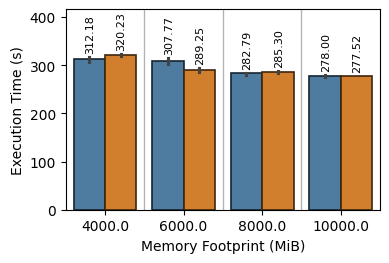

Comparison to 'MANTA' at same MiB
pr-twitter.sg
     MiB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
 4000.00   ARMS       320.23        312.18     8.04          2.58            1.03
 6000.00   ARMS       289.25        307.77   -18.52         -6.02            0.94
 8000.00   ARMS       285.30        282.79     2.50          0.89            1.01
10000.00   ARMS       277.52        278.00    -0.48         -0.17            1.00



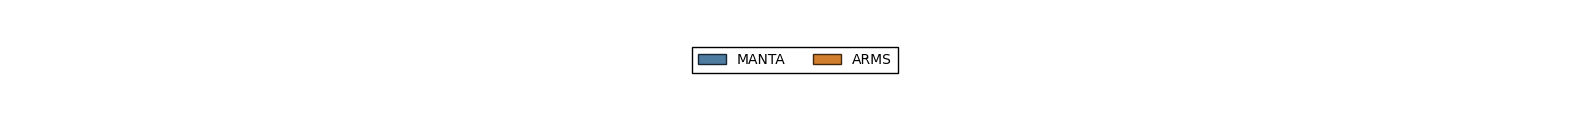

In [53]:
roots_6_18 = lambda workload: {
        #"arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "MANTA": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.18/{workload}")),
        "ARMS": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/arms_6.18/{workload}")),
    }

df = generate_df(roots_6_18)
df_plot = df[df["MiB"].isin([4000, 6000, 8000, 10000])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)
plot_df(df_plot, "6_18")

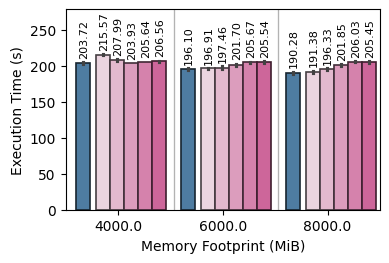

Comparison to 'MANTA' at same MiB
DuckDB-TPCH-sf100
    MiB            policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
4000.00                 MANTA 0.1       203.72        203.72     0.00          0.00            1.00
4000.00 MANTA cost ablation 0.125       215.57        203.72    11.86          5.82            1.06
4000.00  MANTA cost ablation 0.25       207.99        203.72     4.27          2.10            1.02
4000.00   MANTA cost ablation 0.5       203.93        203.72     0.21          0.10            1.00
4000.00   MANTA cost ablation 1.0       205.64        203.72     1.93          0.95            1.01
4000.00   MANTA cost ablation 1.5       206.56        203.72     2.85          1.40            1.01
6000.00                 MANTA 0.1       196.10        196.10     0.00          0.00            1.00
6000.00 MANTA cost ablation 0.125       196.91        196.10     0.81          0.41            1.00
6000.00  MANTA cost ablation 0.25       197.46  

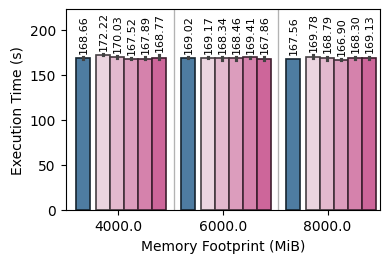

Comparison to 'MANTA' at same MiB
XSBench
    MiB            policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
4000.00                 MANTA 0.1       168.66        168.66     0.00          0.00            1.00
4000.00 MANTA cost ablation 0.125       172.22        168.66     3.56          2.11            1.02
4000.00  MANTA cost ablation 0.25       170.03        168.66     1.38          0.82            1.01
4000.00   MANTA cost ablation 0.5       167.52        168.66    -1.13         -0.67            0.99
4000.00   MANTA cost ablation 1.0       167.89        168.66    -0.77         -0.46            1.00
4000.00   MANTA cost ablation 1.5       168.77        168.66     0.12          0.07            1.00
6000.00                 MANTA 0.1       169.02        169.02     0.00          0.00            1.00
6000.00 MANTA cost ablation 0.125       169.17        169.02     0.14          0.08            1.00
6000.00  MANTA cost ablation 0.25       168.34        169.

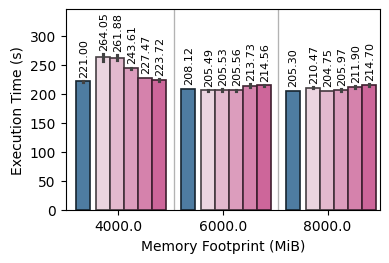

Comparison to 'MANTA' at same MiB
bc-kron.sg
    MiB            policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
4000.00                 MANTA 0.1       221.00        221.00     0.00          0.00            1.00
4000.00 MANTA cost ablation 0.125       264.05        221.00    43.05         19.48            1.19
4000.00  MANTA cost ablation 0.25       261.88        221.00    40.88         18.50            1.18
4000.00   MANTA cost ablation 0.5       243.61        221.00    22.61         10.23            1.10
4000.00   MANTA cost ablation 1.0       227.47        221.00     6.47          2.93            1.03
4000.00   MANTA cost ablation 1.5       223.72        221.00     2.72          1.23            1.01
6000.00                 MANTA 0.1       208.12        208.12     0.00          0.00            1.00
6000.00 MANTA cost ablation 0.125       205.49        208.12    -2.63         -1.26            0.99
6000.00  MANTA cost ablation 0.25       205.53        2

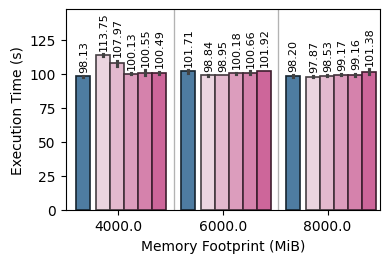

Comparison to 'MANTA' at same MiB
bc-twitter.sg
    MiB            policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
4000.00                 MANTA 0.1        98.13         98.13     0.00          0.00            1.00
4000.00 MANTA cost ablation 0.125       113.75         98.13    15.63         15.92            1.16
4000.00  MANTA cost ablation 0.25       107.97         98.13     9.84         10.03            1.10
4000.00   MANTA cost ablation 0.5       100.13         98.13     2.00          2.04            1.02
4000.00   MANTA cost ablation 1.0       100.55         98.13     2.43          2.47            1.02
4000.00   MANTA cost ablation 1.5       100.49         98.13     2.37          2.41            1.02
6000.00                 MANTA 0.1       101.71        101.71     0.00          0.00            1.00
6000.00 MANTA cost ablation 0.125        98.84        101.71    -2.88         -2.83            0.97
6000.00  MANTA cost ablation 0.25        98.95      

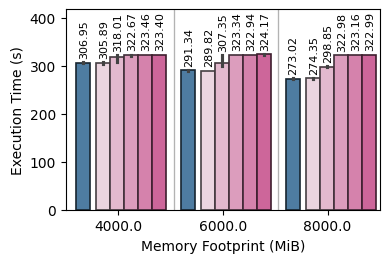

Comparison to 'MANTA' at same MiB
faiss_10M
    MiB            policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
4000.00                 MANTA 0.1       306.95        306.95     0.00          0.00            1.00
4000.00 MANTA cost ablation 0.125       305.89        306.95    -1.06         -0.35            1.00
4000.00  MANTA cost ablation 0.25       318.01        306.95    11.06          3.60            1.04
4000.00   MANTA cost ablation 0.5       322.67        306.95    15.72          5.12            1.05
4000.00   MANTA cost ablation 1.0       323.46        306.95    16.51          5.38            1.05
4000.00   MANTA cost ablation 1.5       323.40        306.95    16.45          5.36            1.05
6000.00                 MANTA 0.1       291.34        291.34     0.00          0.00            1.00
6000.00 MANTA cost ablation 0.125       289.82        291.34    -1.52         -0.52            0.99
6000.00  MANTA cost ablation 0.25       307.35        29

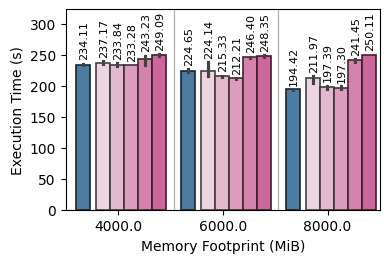

Comparison to 'MANTA' at same MiB
mg.D.x
    MiB            policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
4000.00                 MANTA 0.1       234.11        234.11     0.00          0.00            1.00
4000.00 MANTA cost ablation 0.125       237.17        234.11     3.05          1.30            1.01
4000.00  MANTA cost ablation 0.25       233.84        234.11    -0.27         -0.12            1.00
4000.00   MANTA cost ablation 0.5       233.28        234.11    -0.83         -0.36            1.00
4000.00   MANTA cost ablation 1.0       243.23        234.11     9.12          3.89            1.04
4000.00   MANTA cost ablation 1.5       249.09        234.11    14.98          6.40            1.06
6000.00                 MANTA 0.1       224.65        224.65     0.00          0.00            1.00
6000.00 MANTA cost ablation 0.125       224.14        224.65    -0.51         -0.23            1.00
6000.00  MANTA cost ablation 0.25       215.33        224.6

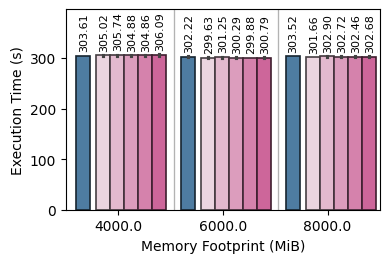

Comparison to 'MANTA' at same MiB
pr-kron.sg
    MiB            policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
4000.00                 MANTA 0.1       303.61        303.61     0.00          0.00            1.00
4000.00 MANTA cost ablation 0.125       305.02        303.61     1.41          0.46            1.00
4000.00  MANTA cost ablation 0.25       305.74        303.61     2.13          0.70            1.01
4000.00   MANTA cost ablation 0.5       304.88        303.61     1.27          0.42            1.00
4000.00   MANTA cost ablation 1.0       304.86        303.61     1.25          0.41            1.00
4000.00   MANTA cost ablation 1.5       306.09        303.61     2.47          0.81            1.01
6000.00                 MANTA 0.1       302.22        302.22     0.00          0.00            1.00
6000.00 MANTA cost ablation 0.125       299.63        302.22    -2.59         -0.86            0.99
6000.00  MANTA cost ablation 0.25       301.25        3

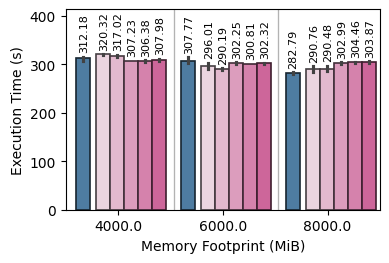

Comparison to 'MANTA' at same MiB
pr-twitter.sg
    MiB            policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
4000.00                 MANTA 0.1       312.18        312.18     0.00          0.00            1.00
4000.00 MANTA cost ablation 0.125       320.32        312.18     8.13          2.61            1.03
4000.00  MANTA cost ablation 0.25       317.02        312.18     4.84          1.55            1.02
4000.00   MANTA cost ablation 0.5       307.23        312.18    -4.95         -1.59            0.98
4000.00   MANTA cost ablation 1.0       306.38        312.18    -5.80         -1.86            0.98
4000.00   MANTA cost ablation 1.5       307.98        312.18    -4.20         -1.35            0.99
6000.00                 MANTA 0.1       307.77        307.77     0.00          0.00            1.00
6000.00 MANTA cost ablation 0.125       296.01        307.77   -11.77         -3.82            0.96
6000.00  MANTA cost ablation 0.25       290.19      

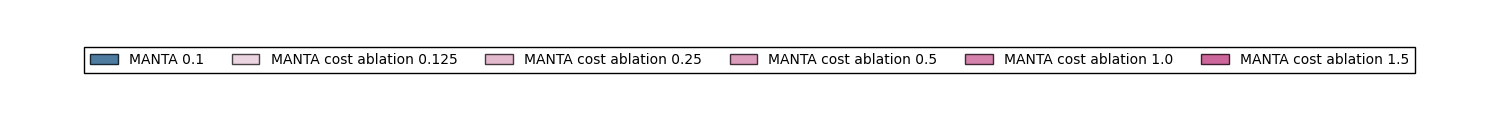

In [54]:
roots_6_18_cost_ablation = lambda workload: {
        "MANTA": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.18/{workload}")),
        "MANTA cost ablation": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.18_cost_ablation/{workload}")),
    }

df = generate_df(roots_6_18_cost_ablation)
df_plot = df[(df["MiB"].isin([4000, 6000, 8000])) & df["penalty"].isin([0.1, 0.125, 0.25, 0.5, 1.0, 1.5])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)
plot_df(df_plot, "6_18_cost_ablation", show_penalty_scaler=True)

In [55]:
models = pd.DataFrame([
    {
        "name": "bc-kron.sg",
        "R2": 0.94,
        "MAE": 14.4,
        "RMSE": 68.83
    },
    {
        "name": "pr-kron.sg",
        "R2": 0.94,
        "MAE": 12.3,
        "RMSE": 125.98
    },
    {
        "name": "bc-twitter.sg",
        "R2": 0.86,
        "MAE": 20.6,
        "RMSE": 132.25
    },
    {
        "name": "pr-twitter.sg",
        "R2": 0.996,
        "MAE": 6.12,
        "RMSE": 58.08
    },
    {
        "name": "faiss_10M",
        "R2": 0.52,
        "MAE": 20.32,
        "RMSE": 445.114
    },
    {
        "name": "mg.D.x",
        "R2": 0.89,
        "MAE": 14.76,
        "RMSE": 382.47
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "R2": 0.85,
        "MAE": 374.43,
        "RMSE": 2725.63
    },{
        "name": "XSBench",
        "R2": 0.91,
        "MAE": 12.66,
        "RMSE": 422.32
    }
])

runs = pd.DataFrame([
    {
        "name": "bc-kron.sg",
        "size": 2,
        "accesses": 150,
        "best scaler": 3.5,
        "weight": 1 
    },
    {
        "name": "bc-kron.sg",
        "size": 4,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-kron.sg",
        "size": 6,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-kron.sg",
        "size": 8,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-twitter.sg",
        "size": 2,
        "accesses": 15,
        "best scaler": .7, 
        "weight": 1
    },
    {
        "name": "bc-twitter.sg",
        "size": 4,
        "accesses": 8,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "bc-twitter.sg",
        "size": 6,
        "accesses": 5,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "bc-twitter.sg",
        "size": 8,
        "accesses": 3,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "pr-kron.sg",
        "size": 2,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 4,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 6,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 8,
        "accesses": 3,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-twitter.sg",
        "size": 2,
        "accesses": 13,
        "best scaler": 1.0, 
        "weight": 1
    },
    {
        "name": "pr-twitter.sg",
        "size": 4,
        "accesses": 10,
        "best scaler": 0.2,
        "weight": 2
    },
    {
        "name": "pr-twitter.sg",
        "size": 6,
        "accesses": 8,
        "best scaler": 0.2,
        "weight": 2
    },
    {
        "name": "pr-twitter.sg",
        "size": 8,
        "accesses": 0,
        "best scaler": 0.0625, 
        "weight": 2
    },
    {
        "name": "mg.D.x",
        "size": 2,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 4,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 6,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 8,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 2,
        "accesses": 350,
        "best scaler": 6.0,
        "weight": 1 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 4,
        "accesses": 150,
        "best scaler": 0.5,
        "weight": 2 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 6,
        "accesses": 150,
        "best scaler": 0.5,
        "weight": 2 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 8,
        "accesses": 100,
        "best scaler": 0.5,
        "weight": 2  
    },
    {
        "name": "XSBench",
        "size": 2,
        "accesses": 0.8,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 4,
        "accesses": 0.7,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 6,
        "accesses": 0.7,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 8,
        "accesses": 0.7,
        "best scaler": 0.5,
        "weight": 0.25
    },
    {
        "name": "faiss_10M",
        "size": 2,
        "accesses": 2.7,
        "best scaler": 0.125,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 4,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 6,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 8,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2 
    },
])

In [56]:
from sklearn.linear_model import LinearRegression

# Merge the dataframes
merged_df = runs.merge(models, on="name", how="left")

# Create and train the linear model
features = ["accesses"]
X = merged_df[features]
y = merged_df["best scaler"]
sample_weight = merged_df["weight"]

model = LinearRegression()
model.fit(X, y, sample_weight=sample_weight)

for feature in features:
    print(f"Coefficient for {feature}: {model.coef_[features.index(feature)]:.4f}")
print(f"Model intercept: {model.intercept_:.4f}")
print(f"R² score: {model.score(X, y, sample_weight=sample_weight):.4f}")

Coefficient for accesses: 0.0114
Model intercept: 0.0936
R² score: 0.6246


In [57]:
merged_df["hand calculated"] = 0.01 * merged_df["accesses"] + .1

In [58]:
merged_df["predicted_best_scaler"] = model.predict(X)
merged_df

,name,size,accesses,best scaler,weight,R2,MAE,RMSE,hand calculated,predicted_best_scaler
0,bc-kron.sg,2,150.00,3.500000,1.00,0.940,14.40,68.830,1.6000,1.806820
1,bc-kron.sg,4,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
2,bc-kron.sg,6,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
3,bc-kron.sg,8,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
4,bc-twitter.sg,2,15.00,0.700000,1.00,0.860,20.60,132.250,0.2500,0.264901
5,bc-twitter.sg,4,8.00,0.200000,2.00,0.860,20.60,132.250,0.1800,0.184950
6,bc-twitter.sg,6,5.00,0.200000,2.00,0.860,20.60,132.250,0.1500,0.150685
7,bc-twitter.sg,8,3.00,0.200000,2.00,0.860,20.60,132.250,0.1300,0.127842
8,pr-kron.sg,2,2.25,0.500000,0.20,0.940,12.30,125.980,0.1225,0.119276
9,pr-kron.sg,4,2.25,0.500000,0.20,0.940,12.30,125.980,0.1225,0.119276


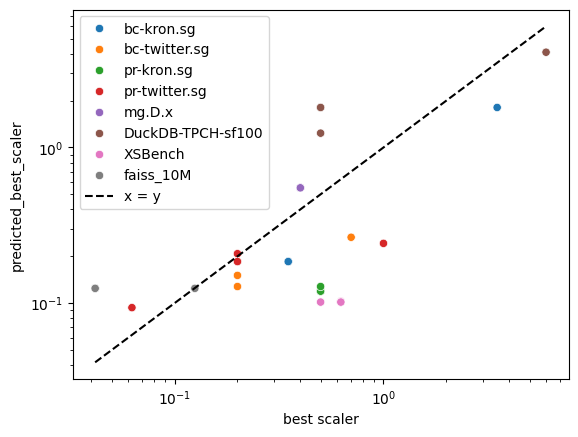

In [59]:

sns.scatterplot(merged_df, x="best scaler", y="predicted_best_scaler", hue="name")
plt.xscale("log")
plt.yscale("log")
ax = plt.gca()
min_val = min(merged_df["best scaler"].min(), merged_df["predicted_best_scaler"].min())
max_val = max(merged_df["best scaler"].max(), merged_df["predicted_best_scaler"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", label="x = y")
ax.legend()
plt.show()